In [1]:
from pathlib import Path
from typing import List, Tuple, Callable
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import UnivariateSpline
import numpy as np

In [2]:
def plot_relative_entropy_single_plot(
    file_paths: List[List[Path]],
    attributes: List[Tuple[str, str]],
    smooth_factor: float = 0.05,  # Set to e.g., 0.05 to enable spline smoothing
):
    # ---------------------------------------------------------
    # 1. Define Pauli Matrices & Helper Functions
    # ---------------------------------------------------------
    pauli_dict = {
        "X": np.array([[0, 1], [1, 0]], dtype=complex),
        "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
        "Z": np.array([[1, 0], [0, -1]], dtype=complex),
    }
    pauli_vec = np.stack([pauli_dict["X"], pauli_dict["Y"], pauli_dict["Z"]], axis=0) # (3, 2, 2)
    
    def matrix_function(M: np.ndarray, fn: Callable, eps: float = 1e-12) -> np.ndarray:
        """Applies a scalar function to the eigenvalues of a batch of matrices."""
        eigvals, eigvecs = np.linalg.eigh(M)
        eigvals = np.clip(eigvals, eps, None)  # Prevent log(0) or log(negative)
        D = np.zeros_like(M, dtype=complex)
        idx = np.arange(M.shape[-1])
        D[..., idx, idx] = fn(eigvals)
        return eigvecs @ D @ eigvecs.conj().swapaxes(-1, -2)

    # ---------------------------------------------------------
    # 2. Setup Plot & Hardcoded Styles
    # ---------------------------------------------------------
    plt.figure(figsize=(16, 5), dpi=200)
    
    markers = ["x", "o", "^", "+"]
    line_styles = ["-", "-", "--", "--"]
    colors = ["salmon", "firebrick", "darkviolet", "hotpink"]
    marker_size = 8

    # ---------------------------------------------------------
    # 3. Data Processing Loop
    # ---------------------------------------------------------
    for i, (pair_file_path, attribute) in enumerate(zip(file_paths, attributes)):
        
        fp1, fp2 = pair_file_path
        main_qubit_states, spectator_qubit_states = attribute
        
        # Load data
        df1 = pd.read_csv(fp1)
        df2 = pd.read_csv(fp2)

        req_cols = {"X_mean", "Y_mean", "Z_mean"}
        if not (req_cols.issubset(df1.columns) and req_cols.issubset(df2.columns)):
            raise ValueError("Both CSVs must contain X_mean, Y_mean, Z_mean columns")
        
        t1 = df1.iloc[:, 0].to_numpy()
        t2 = df2.iloc[:, 0].to_numpy()
        if not np.array_equal(t1, t2):
            raise ValueError("The time points t1 and t2 must be identical")
        
        # Extract Bloch vectors, shape: (T, 3)
        bloch1 = df1[["X_mean", "Y_mean", "Z_mean"]].to_numpy()
        bloch2 = df2[["X_mean", "Y_mean", "Z_mean"]].to_numpy()

        # Construct density matrices: rho = 0.5 * (I + xX + yY + zZ)
        rho1 = 0.5 * (np.eye(2) + np.tensordot(bloch1, pauli_vec, axes=[[1], [0]]))
        rho2 = 0.5 * (np.eye(2) + np.tensordot(bloch2, pauli_vec, axes=[[1], [0]]))
        
        # Enforce positive semi-definiteness & unit trace to handle experimental noise
        rho1 = matrix_function(rho1, np.abs)
        rho1 = rho1 / np.trace(rho1, axis1=-2, axis2=-1)[..., None, None]
        
        rho2 = matrix_function(rho2, np.abs)
        rho2 = rho2 / np.trace(rho2, axis1=-2, axis2=-1)[..., None, None]

        # Calculate Quantum Relative Entropy: D(rho1 || rho2)
        log_rho1 = matrix_function(rho1, np.log2)
        log_rho2 = matrix_function(rho2, np.log2)
        relative_entropy = np.trace(rho1 @ (log_rho1 - log_rho2), axis1=-2, axis2=-1).real
        
        # -----------------------------------------------------
        # 4. Plotting
        # -----------------------------------------------------
        main_qubit_states = main_qubit_states.split(",")
        main_qubit_states = ",".join([f"|{s}\\rangle" for s in main_qubit_states])
        spectator_qubit_states = f"|{spectator_qubit_states}\\rangle"
        
        label_str = f"$s_{{\\text{{main}}}}={main_qubit_states}$, $s_{{\\text{{spect}}}}={spectator_qubit_states}$"
        c = colors[i % len(colors)]
        m = markers[i % len(markers)]
        ls = line_styles[i % len(line_styles)]
        
        if smooth_factor is not None:
            # Plot raw data points lightly
            plt.plot(t1, relative_entropy, marker=m, ls='', color=c, alpha=0.6, markersize=marker_size)
            # Plot smoothed curve using the specified line style
            spline = UnivariateSpline(t1, relative_entropy, s=smooth_factor)
            t_smooth = np.linspace(min(t1), max(t1), 500)
            plt.plot(t_smooth, spline(t_smooth), ls=ls, linewidth=1.5, color=c, alpha=0.7, label=label_str)
        else:
            # Standard plot
            plt.plot(t1, relative_entropy, label=label_str, marker=m, ls=ls, 
                     markersize=marker_size, alpha=alpha, color=c)
        
    # ---------------------------------------------------------
    # 5. Finalize Plot Formatting
    # ---------------------------------------------------------
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.title("Quantum Relative Entropy between two states", fontsize=16, pad=20)
    plt.legend(loc="upper right", frameon=True, fontsize=15)
    plt.ylabel("$D(\\rho(t_1) \\Vert \\rho(t_2))$", fontsize=15, labelpad=20)
    plt.xlabel("$t$ $(\\mu s)$", fontsize=15)
    plt.xlim(left=0.0)
    plt.ylim([0.0, 2.0]) 
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    # plt.show()
    plt.savefig("images/quantum_relative_entropy.pdf", dpi=300, bbox_inches='tight')

In [3]:
def plot_trace_distance_single_plot(
    file_paths: List[List[Path]],
    attributes: List[Tuple[str, str]],
    smooth_factor: float = 0.0001,  # Set to e.g., 0.05 to enable spline smoothing
):
    # ---------------------------------------------------------
    # 1. Define Pauli Matrices & Helper Functions
    # ---------------------------------------------------------
    pauli_dict = {
        "X": np.array([[0, 1], [1, 0]], dtype=complex),
        "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
        "Z": np.array([[1, 0], [0, -1]], dtype=complex),
    }
    pauli_vec = np.stack([pauli_dict["X"], pauli_dict["Y"], pauli_dict["Z"]], axis=0) # (3, 2, 2)
    
    def matrix_function(M: np.ndarray, fn: Callable, eps: float = 1e-12) -> np.ndarray:
        """Applies a scalar function to the eigenvalues of a batch of matrices."""
        eigvals, eigvecs = np.linalg.eigh(M)
        eigvals = np.clip(eigvals, eps, None)  # Prevent log(0) or log(negative)
        D = np.zeros_like(M, dtype=complex)
        idx = np.arange(M.shape[-1])
        D[..., idx, idx] = fn(eigvals)
        return eigvecs @ D @ eigvecs.conj().swapaxes(-1, -2)

    # ---------------------------------------------------------
    # 2. Setup Plot & Hardcoded Styles
    # ---------------------------------------------------------
    plt.figure(figsize=(16, 5), dpi=200)
    
    markers = ["x", "o", "^", "+"]
    line_styles = ["-", "-", "--", "--"]
    colors = ["salmon", "firebrick", "darkviolet", "hotpink"]
    marker_size = 8
    alpha = 0.8  # Added alpha definition

    # ---------------------------------------------------------
    # 3. Data Processing Loop
    # ---------------------------------------------------------
    for i, (pair_file_path, attribute) in enumerate(zip(file_paths, attributes)):
        
        fp1, fp2 = pair_file_path
        main_qubit_states, spectator_qubit_states = attribute
        
        # Load data
        df1 = pd.read_csv(fp1)
        df2 = pd.read_csv(fp2)

        req_cols = {"X_mean", "Y_mean", "Z_mean"}
        if not (req_cols.issubset(df1.columns) and req_cols.issubset(df2.columns)):
            raise ValueError("Both CSVs must contain X_mean, Y_mean, Z_mean columns")
        
        t1 = df1.iloc[:, 0].to_numpy()
        t2 = df2.iloc[:, 0].to_numpy()
        if not np.array_equal(t1, t2):
            raise ValueError("The time points t1 and t2 must be identical")
        
        # Extract Bloch vectors, shape: (T, 3)
        bloch1 = df1[["X_mean", "Y_mean", "Z_mean"]].to_numpy()
        bloch2 = df2[["X_mean", "Y_mean", "Z_mean"]].to_numpy()

        # Construct density matrices: rho = 0.5 * (I + xX + yY + zZ)
        rho1 = 0.5 * (np.eye(2) + np.tensordot(bloch1, pauli_vec, axes=[[1], [0]]))
        rho2 = 0.5 * (np.eye(2) + np.tensordot(bloch2, pauli_vec, axes=[[1], [0]]))
        
        # Enforce positive semi-definiteness & unit trace to handle experimental noise
        rho1 = matrix_function(rho1, np.abs)
        rho1 = rho1 / np.trace(rho1, axis1=-2, axis2=-1)[..., None, None]
        
        rho2 = matrix_function(rho2, np.abs)
        rho2 = rho2 / np.trace(rho2, axis1=-2, axis2=-1)[..., None, None]

        # Calculate Trace Distance: 1/2 ||rho1 - rho2||_1
        # Since rho1 - rho2 is Hermitian, the trace norm is the sum of absolute eigenvalues
        delta_rho = rho1 - rho2
        eigvals = np.linalg.eigvalsh(delta_rho)
        trace_distance = 0.5 * np.sum(np.abs(eigvals), axis=-1)
        
        # -----------------------------------------------------
        # 4. Plotting
        # -----------------------------------------------------
        main_qubit_states = main_qubit_states.split(",")
        main_qubit_states = ",".join([f"|{s}\\rangle" for s in main_qubit_states])
        spectator_qubit_states = f"|{spectator_qubit_states}\\rangle"
        
        label_str = f"$s_{{\\text{{main}}}}={main_qubit_states}$, $s_{{\\text{{spect}}}}={spectator_qubit_states}$"
        c = colors[i % len(colors)]
        m = markers[i % len(markers)]
        ls = line_styles[i % len(line_styles)]
        
        if smooth_factor is not None:
            # Plot raw data points lightly
            plt.plot(t1, trace_distance, marker=m, ls='', color=c, alpha=0.6, markersize=marker_size)
            # Plot smoothed curve using the specified line style
            spline = UnivariateSpline(t1, trace_distance, s=smooth_factor)
            t_smooth = np.linspace(min(t1), max(t1), 500)
            plt.plot(t_smooth, spline(t_smooth), ls=ls, linewidth=1.5, color=c, alpha=0.7, label=label_str)
        else:
            # Standard plot
            plt.plot(t1, trace_distance, label=label_str, marker=m, ls=ls, 
                     markersize=marker_size, alpha=alpha, color=c)
        
    # ---------------------------------------------------------
    # 5. Finalize Plot Formatting
    # ---------------------------------------------------------
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.title("Trace Distance between two states", fontsize=16, pad=20)
    plt.legend(loc="upper right", frameon=True, fontsize=15)
    plt.ylabel("$T(\\rho(t_1), \\rho(t_2))$", fontsize=15, labelpad=20)
    plt.xlabel("$t$ $(\\mu s)$", fontsize=15)
    plt.xlim(left=0.0)
    plt.ylim([0.0, 1.05]) # Trace distance is bounded between 0 and 1
    plt.grid(True, alpha=0.3, linestyle="--")
    plt.tight_layout()
    # plt.show()
    plt.savefig("images/trace_distance.pdf", dpi=300, bbox_inches='tight')

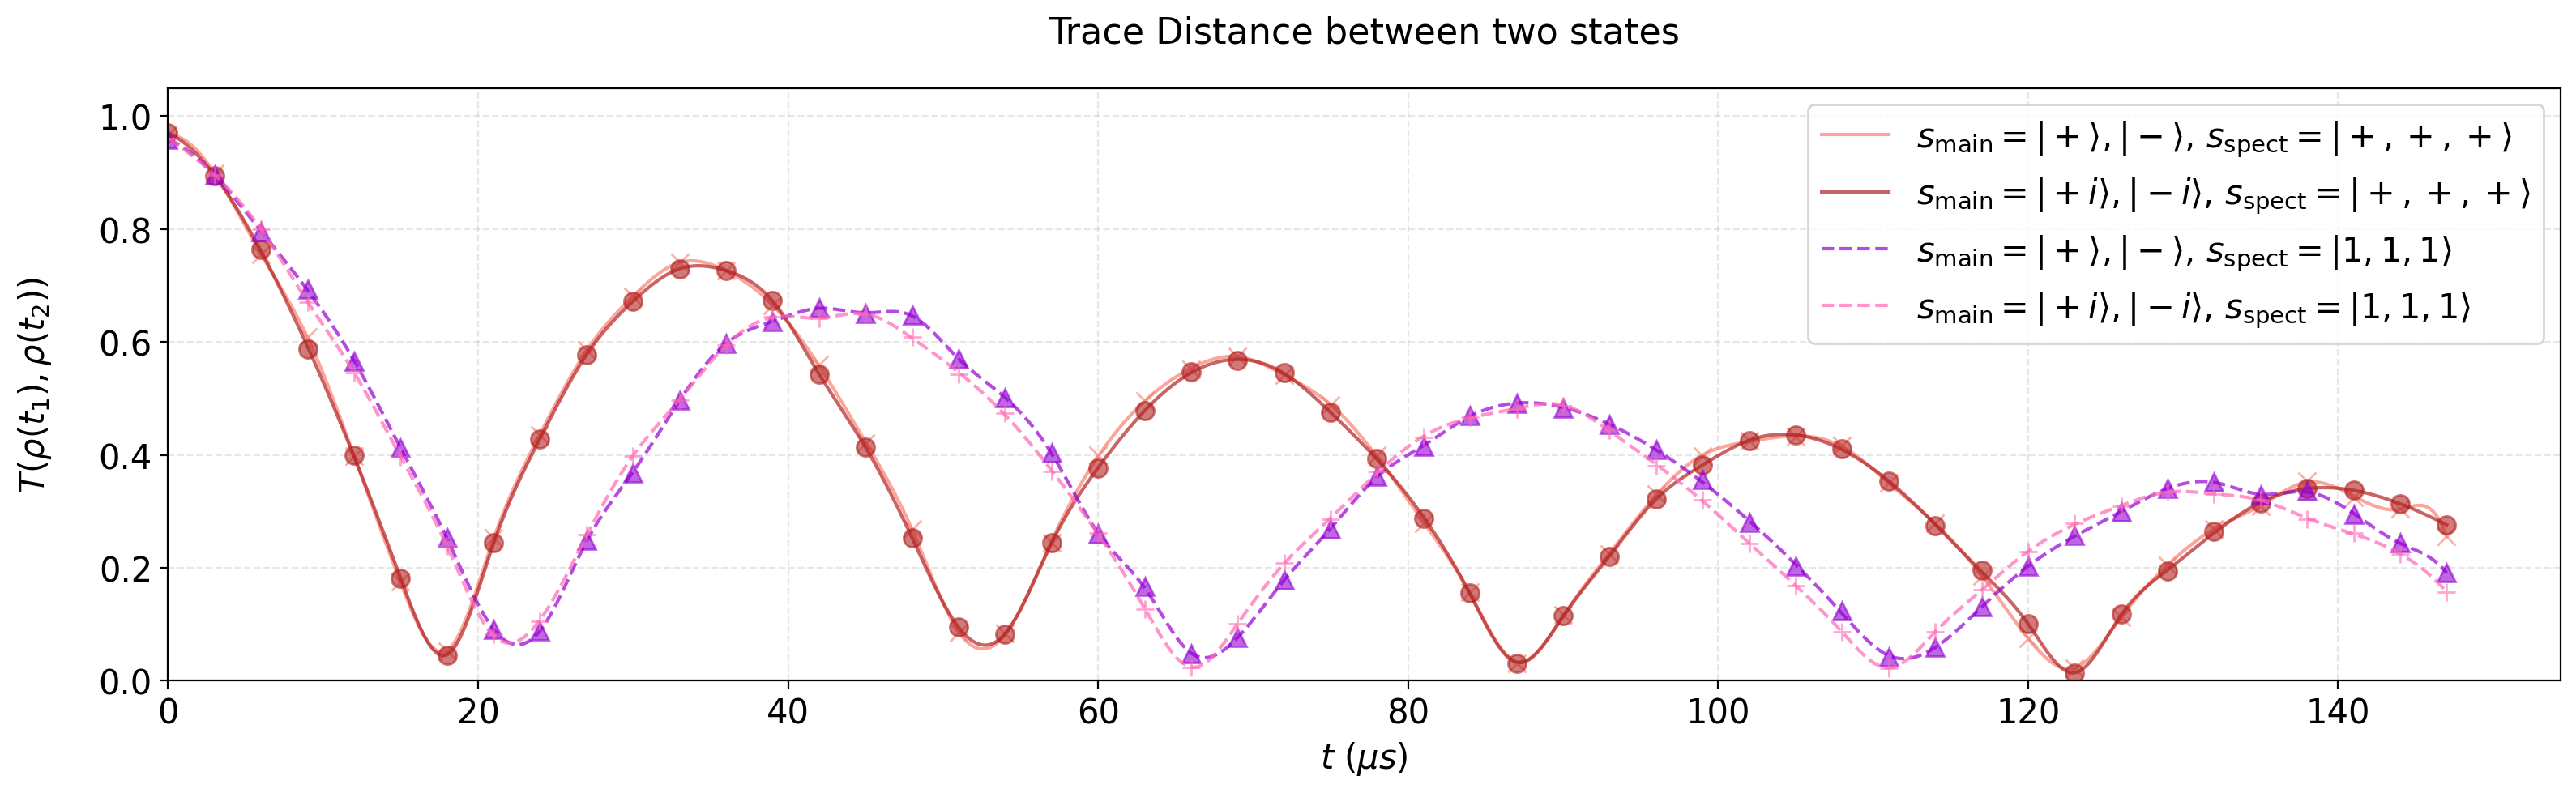

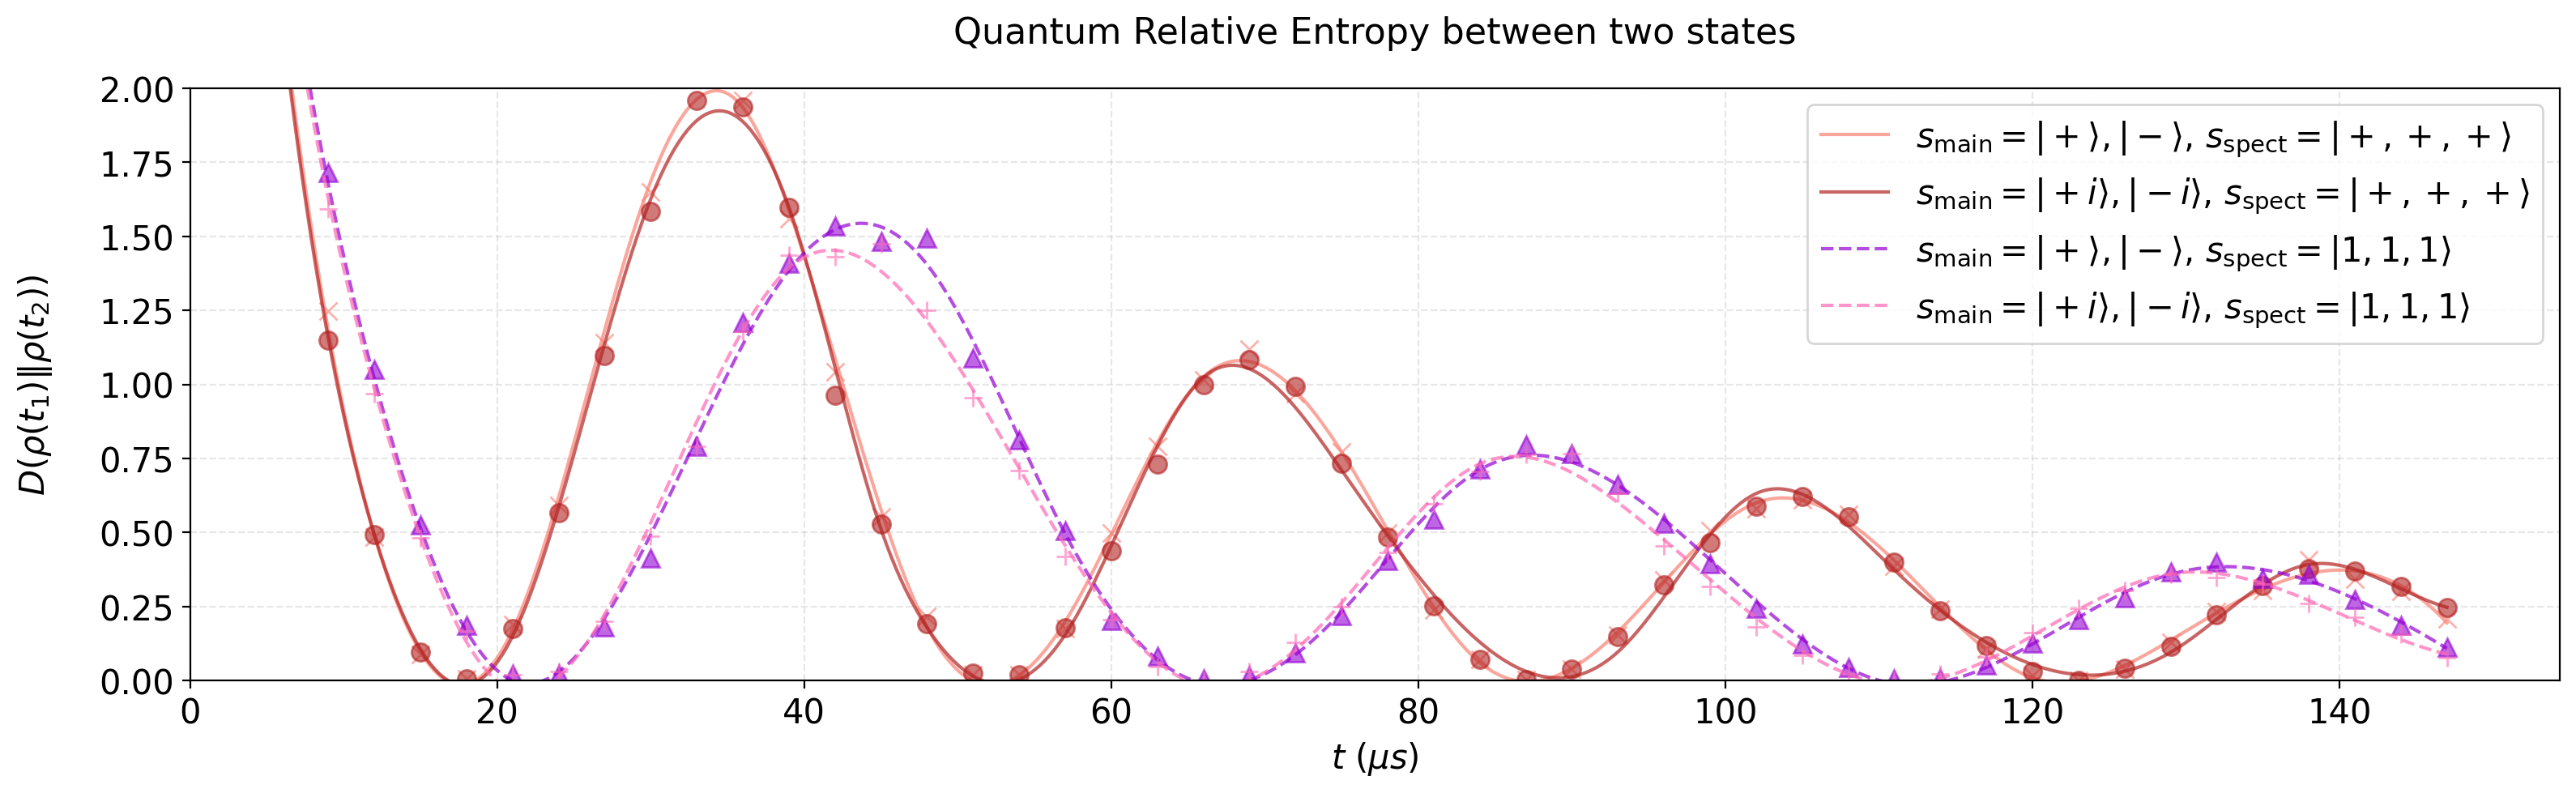

In [4]:
files1 = [
    "results/state_tomography/crosstalk/ibm_brussels/init+,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T16-59-57.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-07-46.csv"
]

files2 = [
    "results/state_tomography/crosstalk/ibm_brussels/init+i,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-15-31.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-i,+,+,+/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T17-23-17.csv"
]

files3 = [
    "results/state_tomography/crosstalk/ibm_brussels/init+,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-12-36.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-20-21.csv"
]

files4 = [
    "results/state_tomography/crosstalk/ibm_brussels/init+i,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-28-07.csv",
    "results/state_tomography/crosstalk/ibm_brussels/init-i,1,1,1/bloch-q[49, 48, 50, 55]-np50-gpp50-s8192-2025-05-05T20-35-53.csv"
]

file_paths = [files1, files2, files3, files4]

attributes = [
    ("+,-", "+,+,+"), ("+i,-i", "+,+,+"), ("+,-", "1,1,1"), ("+i,-i", "1,1,1"),
]

plot_trace_distance_single_plot(file_paths, attributes)

plot_relative_entropy_single_plot(file_paths, attributes)